# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus | | | | | |
| Procesamiento con spaCy | | | | | |
| Representaciones sparse | | | | | |
| Visualización | | | | | |
| Interpretación final | | | | | |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [3]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)



print("Entorno cargado correctamente.")


Entorno cargado correctamente.


## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.


In [4]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_final.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 6               # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_final.csv
Columna de contraste: grupo_comparacion


>El TP se centra en el análisis de tres notas de medios "grupo": "Independiente/Investigación" y tres medios 
>"grupo": "Afin/Oficialista"

In [5]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from trafilatura import fetch_url, extract
import notas_seleccionadas

# scrap de paginas
def scrape_noticia(url_data):
    downloaded = fetch_url(url_data['url'])
    # aplicamos Trafilatura
    content = extract(downloaded)
    
    # Si falla, usamos BeautifulSoup
    if not content:
        response = requests.get(url_data['url'])
        soup = BeautifulSoup(response.text, 'html.parser')
        content = ' '.join([p.text for p in soup.find_all('p')])
    
    return content

# 2. Ejecución del Scraping
corpus_list = []

print("scrapeo de las paginas")

for i, u in enumerate(notas_seleccionadas.urls):
    print(f"Scrapeando {i+1}/6: {u['medio']}...")
    texto_limpio = scrape_noticia(u)
    
    # título de la página 
    res = requests.get(u['url'])
    s = BeautifulSoup(res.text, 'html.parser')
    titulo = s.title.string if s.title else "Sin título"

    corpus_list.append({
        "id": i + 1,
        "fecha": u['fecha'],
        "medio": u['medio'],
        "autor": u['autor'],
        "titulo": titulo.strip(),
        "texto": texto_limpio,
        "grupo_comparacion": u['grupo']
    })

# creo el DataFrame
df_final = pd.DataFrame(corpus_list)

# quitar saltos de líneas
df_final['texto'] = df_final['texto'].str.replace(r'\n+', ' ', regex=True)

# persistencia del corpus en CSV
df_final.to_csv("corpus_final.csv", index=False, encoding='utf-8-sig')
print("\n¡Corpus listo! Archivo 'corpus_final.csv' generado.")
print(df_final[['medio', 'grupo_comparacion']].value_counts())

scrapeo de las paginas
Scrapeando 1/6: Perfil...
Scrapeando 2/6: Perfil...
Scrapeando 3/6: Pagina12...
Scrapeando 4/6: Infobae...
Scrapeando 5/6: El Cronista...
Scrapeando 6/6: Infobae...

¡Corpus listo! Archivo 'corpus_final.csv' generado.
medio        grupo_comparacion          
Perfil       Independiente/Investigación    2
Infobae      Afin/Oficialista               2
Pagina12     Independiente/Investigación    1
El Cronista  Afin/Oficialista               1
Name: count, dtype: int64


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [6]:
print(df_final[df_final['texto'].isna()])

Empty DataFrame
Columns: [id, fecha, medio, autor, titulo, texto, grupo_comparacion]
Index: []


In [7]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = [
    "id", 
    "fecha", 
    "medio", 
    "autor", 
    "titulo", 
    COLUMNA_TEXTO, 
    COLUMNA_GRUPO
    ]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 6
Grupos detectados: ['Afin/Oficialista', 'Independiente/Investigación']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2026-05-05,Perfil,Barbara Komarovsky,El arquitecto que hizo las refacciones en la casa del country de Adorni dijo que no emitió facturas | Perfil,Independiente/Investigación,1091
1,2,2026-05-06,Perfil,Fabian Waldman,"Fabián Waldman puso en duda en ""QR!"" la versión de Adorni por gastos en dólares | Canal E",Independiente/Investigación,439
2,3,2026-07-05,Pagina12,Redacción,Adorni está en una cuerda cada vez más floja – Página|12,Independiente/Investigación,48
3,4,2026-04-16,Infobae,Eduardo Aulicino,El caso Adorni sigue sumando capítulos y conspira contra el intento oficialista de recrear expectativas - Infobae,Afin/Oficialista,1082
4,5,2026-04-29,El Cronista,Redacción,"Tras dar explicaciones en el Congreso, Adorni confirmó que no renunciará: “Jamás voy a ceder” - El Cronista",Afin/Oficialista,434
5,6,2026-04-29,Infobae,David Cayón,"Manuel Adorni en el Congreso, en vivo: “Quiero dejarles en claro a todos que no voy a renunciar” - Infobae",Afin/Oficialista,935


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


>Comparamos textos de dos grupos de medios sobre el jefe de gabinete Manuel Adorni y las denuncias en su contra (nombres, cargos, instituciones).

>seleccionamos notas de (abril-mayo 2026), para tratar temas similares con foco en Manuel Adorni

> podremos verificar si se produce diferencias en los términos utilizados.

>Al ser de 6 textos, no se puede generalizar estadísticamente a todos los medios.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [8]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,6
1,palabras aproximadas,4029
2,promedio por texto,671.5
3,grupo 1,Afin/Oficialista
4,grupo 2,Independiente/Investigación


In [9]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,Afin/Oficialista,3,2451,817.0
1,Independiente/Investigación,3,1578,526.0


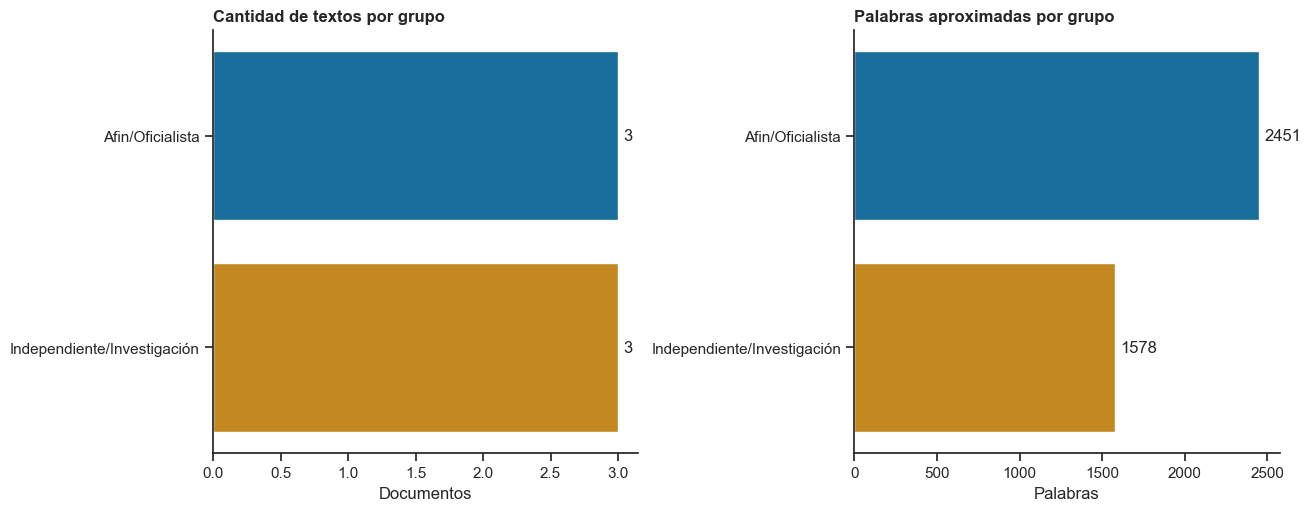

In [10]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_18056\1196760430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


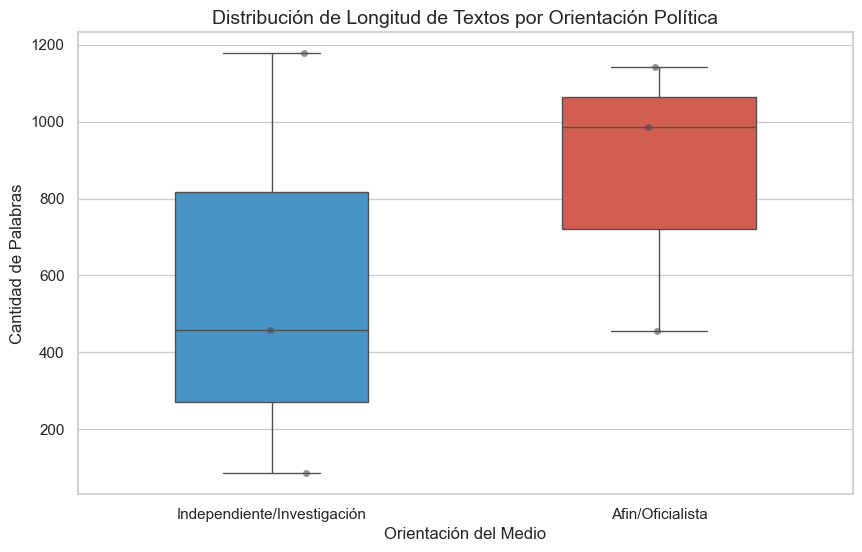

In [11]:
# Seteamos el estilo para que sea accesible y profesional
sns.set_theme(style="whitegrid")
palette = {"Independiente/Investigación": "#3498db", "Afin/Oficialista": "#e74c3c"} # Colores claros para distinguir

# 1. Creamos una columna de longitud de palabras
df['longitud_palabras'] = df['texto'].apply(lambda x: len(str(x).split()))

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df, 
    x='grupo_comparacion', 
    y='longitud_palabras', 
    palette=palette,
    width=0.5
)

# Agregamos los puntos individuales (stripplot) para mostrar los 6 textos de cada lado
sns.stripplot(
    data=df, 
    x='grupo_comparacion', 
    y='longitud_palabras', 
    color=".3", 
    size=5, 
    alpha=0.6
)

plt.title('Distribución de Longitud de Textos por Orientación Política', fontsize=14)
plt.xlabel('Orientación del Medio', fontsize=12)
plt.ylabel('Cantidad de Palabras', fontsize=12)

plt.show()

**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


> Podemos observar que el grupo Independiente/Investigación tiene una mediana de 450 y la longitud de los textos es muy distinta


> para el grupo Afín/Oficialista tiene una mediana casi de 900 y la longitud de los textos también son distintos pero no tanto como el otro grupo


## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [12]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


In [13]:
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

Modelo cargado: es_core_news_sm
Pipeline activo:


0            tok2vec
1      morphologizer
2             parser
3    attribute_ruler
4         lemmatizer
5                ner
dtype: str

In [14]:
print(f"Corpus cargado: {len(df)} textos. Procesando con spaCy...")
print(df[[COLUMNA_TEXTO, COLUMNA_GRUPO]].head(6))
# 
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head(6))


Corpus cargado: 6 textos. Procesando con spaCy...
                                                                                                                                         texto  \
0  En un nuevo capítulo en la causa que investiga al jefe de Gabinete, Manuel Adorni, por enriquecimiento ilícito, este lunes declaró duran...   
1  En la previa del programa “QR!” de Canal E, el periodista Fabián Waldman aseguró que Manuel Adorni “está muy complicado” en medio de las...   
2  VIVO MIRÁ - Edición Impresa - 50 Años del Golpe - El País - Economía - Sociedad - Deportes - El Mundo - Opinión - Contratapa - Recordato...   
3  El Gobierno encadenó un discurso de Javier Milei y varias declaraciones de Luis Caputo -antes y después del nuevo visto bueno del FMI- p...   
4  En esta noticia El jefe de Gabinete, Manuel Adorni, habló este viernes días después de haber expuesto en el Congreso, en medio de la inv...   
5  El jefe de Gabinete, Manuel Adorni, presentó este miércoles en la Cámar

,titulo,grupo_comparacion,texto_contenido
0,El arquitecto que hizo las refacciones en la casa del country de Adorni dijo que no emitió facturas | Perfil,Independiente/Investigación,capítulo causa investigar jefe gabinete manuel adorni enriquecimiento ilícito lunes declarar hora calidad testigo arquitecto matías taba...
1,"Fabián Waldman puso en duda en ""QR!"" la versión de Adorni por gastos en dólares | Canal E",Independiente/Investigación,previa programa qr canal periodista fabián waldman manuel adorni complicado denuncia presunto irregularidad transacción mil dólares cues...
2,Adorni está en una cuerda cada vez más floja – Página|12,Independiente/Investigación,vivo mirá edición impresa año golpe país economía sociedad deportes mundo opinión contratapa recordatorios cultura cash radio radar rada...
3,El caso Adorni sigue sumando capítulos y conspira contra el intento oficialista de recrear expectativas - Infobae,Afin/Oficialista,gobierno encadenar discurso javier milei declaración luis caputo visto tratar amortiguar número negativo economía inflación punto destac...
4,"Tras dar explicaciones en el Congreso, Adorni confirmó que no renunciará: “Jamás voy a ceder” - El Cronista",Afin/Oficialista,noticia jefe gabinete manuel adorni hablar viernes exponer congreso investigación judicial causa investigar compra departamento gollete ...
5,"Manuel Adorni en el Congreso, en vivo: “Quiero dejarles en claro a todos que no voy a renunciar” - Infobae",Afin/Oficialista,jefe gabinete manuel adorni presentar miércoles cámara diputados nación informe gestión sesión atravesado fuerte clima político presenci...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [15]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    registros = []
    
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        # La clave es convertir cada fila en string y luego unir todo
        # Usamos .astype(str) para evitar el error de 'float' que tuviste antes
        texto_consolidado = " ".join(subconjunto["texto_contenido"].astype(str))
        
        # Limpiamos posibles caracteres de formato de lista si quedaron del pre-procesamiento
        texto_limpio = texto_consolidado.replace("[", "").replace("]", "").replace("'", "").replace(",", "")
        
        contador = Counter(texto_limpio.split())
        
        for termino, frecuencia in contador.most_common(top_n):
            registros.append({
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)

top_terminos = obtener_top_terminos_por_grupo(df, top_n=10)
display(top_terminos)

,grupo,término,frecuencia
0,Afin/Oficialista,adorni,28
1,Afin/Oficialista,gabinete,16
2,Afin/Oficialista,jefe,15
3,Afin/Oficialista,manuel,14
4,Afin/Oficialista,causa,10
5,Afin/Oficialista,sesión,10
6,Afin/Oficialista,informe,9
7,Afin/Oficialista,congreso,9
8,Afin/Oficialista,bloque,9
9,Afin/Oficialista,funcionario,8


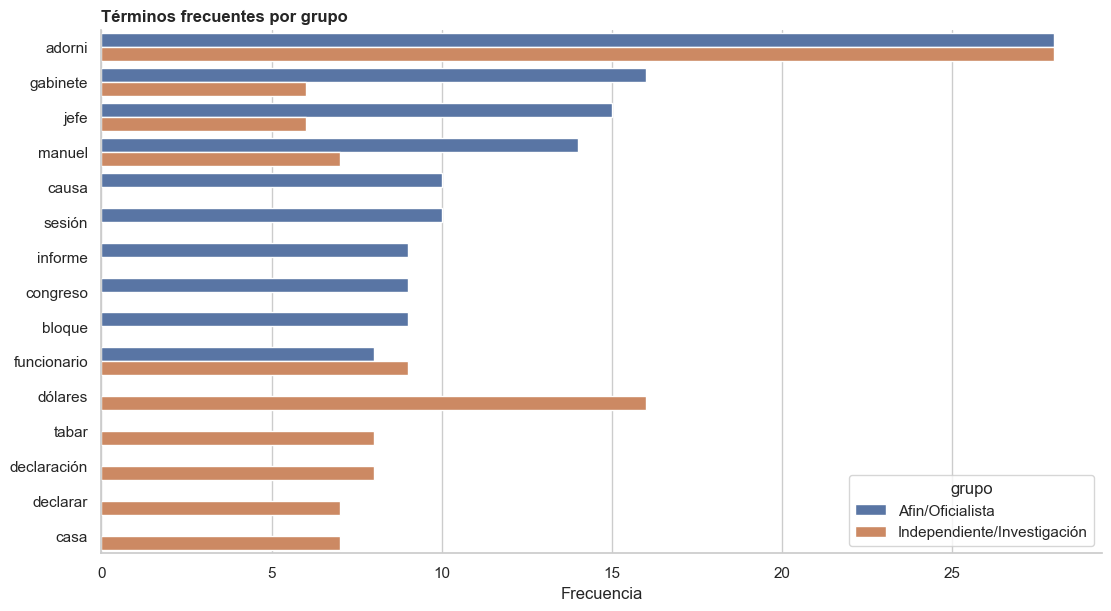

In [16]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [17]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO),
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
76,Afin/Oficialista,Manuel Adorni,PER,14
2,Afin/Oficialista,Adorni,LOC,12
46,Afin/Oficialista,Gabinete,PER,12
89,Afin/Oficialista,PUBLICIDAD,ORG,8
17,Afin/Oficialista,Congreso,ORG,6
116,Afin/Oficialista,Unión,PER,6
61,Afin/Oficialista,Justicia,MISC,5
59,Afin/Oficialista,Javier Milei,PER,3
90,Afin/Oficialista,Patria,ORG,3
102,Afin/Oficialista,Rodolfo Tailhade,PER,3


In [18]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"])

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,Afin/Oficialista,jefe gabinete,15
1,Afin/Oficialista,manuel adorni,14
2,Afin/Oficialista,unión patria,6
3,Afin/Oficialista,bloque unión,6
4,Afin/Oficialista,informe gestión,5
5,Afin/Oficialista,cámara diputados,4
6,Independiente/Investigación,manuel adorni,7
7,Independiente/Investigación,jefe gabinete,6
8,Independiente/Investigación,declaración jurado,4
9,Independiente/Investigación,dólares viaje,3


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


>Más allá de las frecuencias brutas, observamos que la serie Independiente/Investigación se organiza bajo el eje de 'causa y informe', donde entidades como la Camara de diputados validan el discurso crítico. Por el contrario, la serie Afín/Oficialista se estructura sobre el eje de 'funcionario y declaración', poniendo a las declaraciones del ministro como una estrategia de defensa.


>Reconocemos que hay términos requieren ser quitados porque no aportan para el análisis,la frecuencia por sí sola no agota el análisis.


## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [19]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,Afin/Oficialista,gobierno encadenar discurso javier milei declaración luis caputo visto tratar amortiguar número negativo economía inflación punto destac...
1,Independiente/Investigación,capítulo causa investigar jefe gabinete manuel adorni enriquecimiento ilícito lunes declarar hora calidad testigo arquitecto matías taba...


In [20]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"])
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,Afin/Oficialista,sesión,10.0
1,Afin/Oficialista,bloque,9.0
2,Afin/Oficialista,respuesta,8.0
3,Afin/Oficialista,diputados,7.0
4,Afin/Oficialista,patria,6.0
5,Afin/Oficialista,unión,6.0
6,Independiente/Investigación,tabar,8.0
7,Independiente/Investigación,declarar,7.0
8,Independiente/Investigación,dinero,6.0
9,Independiente/Investigación,waldman,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,Afin/Oficialista,sesión,0.2495
1,Afin/Oficialista,bloque,0.2245
2,Afin/Oficialista,respuesta,0.1996
3,Afin/Oficialista,diputados,0.1746
4,Afin/Oficialista,patria,0.1497
5,Afin/Oficialista,unión,0.1497
6,Independiente/Investigación,tabar,0.2659
7,Independiente/Investigación,declarar,0.2327
8,Independiente/Investigación,dinero,0.1994
9,Independiente/Investigación,waldman,0.1994


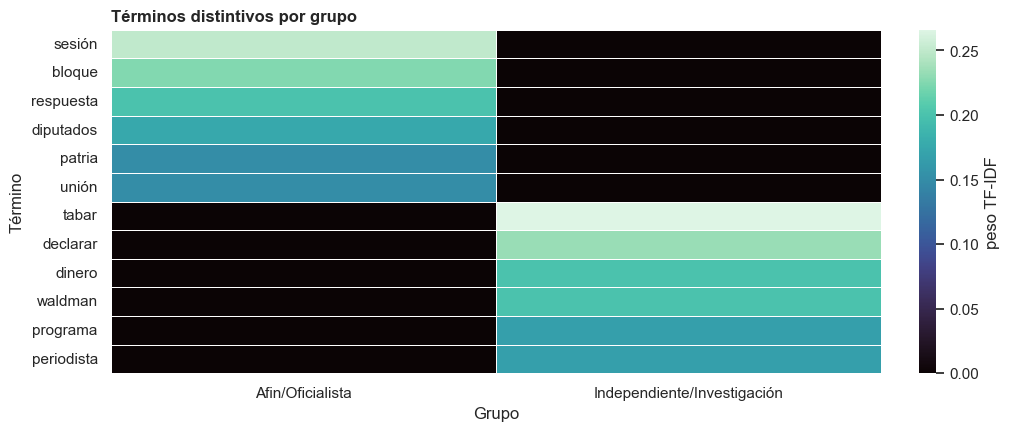

In [21]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


>Los términos más frecuentes en el grupo Afín/Oficialista (sesión, bloque, respuesta, diputados) se centran en la dinámica parlamentaria y el acto institucional del informe de gestión.


>el grupo Afín/Oficialista describe el escenario político (sesión, respuesta), el grupo Independiente/Investigación se concentra en sujetos y objetos de la denuncia (tabar —(testigo), declarar, dinero).


>grupo Afín/Oficialista:


>sesión (0.2495) y bloque (0.2245): Estos términos tienen el TF-IDF más alto del grupo. Esto indica que el discurso oficialista está concentrado en la defensa de la cámara de diputados.


>grupo Independiente/Investigación:


>tabar (0.2662): Es el término con mayor valor de TF-IDF de todo el análisis. Esto se refiere a un testigo clave de la investigación que el grupo Afín/Oficialista ignora por completo.


>dinero (0.1997): término asociado a la corrupción. Mientras que el grupo Afín/Oficialista habla de "sesión", este grupo  Independiente/Investigación habla de "dinero" y nombres de testigos.


## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [22]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,Afin/Oficialista,sesión,0.2495
1,Afin/Oficialista,bloque,0.2245
2,Independiente/Investigación,tabar,0.2659
3,Independiente/Investigación,declarar,0.2327


In [23]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,Afin/Oficialista,sesión,El caso Adorni sigue sumando capítulos y conspira contra el intento oficialista de recrear expectativas - Infobae,"...l cálculo de algunos espacios incluye, aunque con cautela, el repaso de los intentos -también apuntados a Karina Milei- durante la re..."
1,Afin/Oficialista,sesión,"Manuel Adorni en el Congreso, en vivo: “Quiero dejarles en claro a todos que no voy a renunciar” - Infobae","El jefe de Gabinete, Manuel Adorni, presentó este miércoles en la Cámara de Diputados de la Nación su informe de gestión, en una sesión ..."
2,Afin/Oficialista,bloque,"Manuel Adorni en el Congreso, en vivo: “Quiero dejarles en claro a todos que no voy a renunciar” - Infobae",...o de Manuel Adorni por el Congreso Adorni planteó que el éxito del Gobierno será eliminar al kirchnerismo “para siempre” En su respue...
3,Independiente/Investigación,tabar,El arquitecto que hizo las refacciones en la casa del country de Adorni dijo que no emitió facturas | Perfil,"...Gabinete, Manuel Adorni, por enriquecimiento ilícito, este lunes declaró durante unas tres horas en calidad de testigo el arquitecto ..."
4,Independiente/Investigación,declarar,El arquitecto que hizo las refacciones en la casa del country de Adorni dijo que no emitió facturas | Perfil,...de presentarse este lunes en los tribunales de Comodoro Py 2002. Y que el abogado de la empresa le dijo que no llame a nadie y que fu...
5,Independiente/Investigación,declarar,"Fabián Waldman puso en duda en ""QR!"" la versión de Adorni por gastos en dólares | Canal E","...da a presuntos aprietes a un contratista, por lo que pidió la detención del funcionario. A esto se agregaron llamados a personas que ..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


>En el TP estamos comparando el tratamiento de noticias de dos grupos de medios sobre un mismo evento.

>Son válidos porque reaccionan a los mismos hechos en el mismo periodo de tiempo, pero desde agendas opuestas.

>El grupo Afín/Oficialista usa términos como sesión, bloque y diputados para dar un discurso institucional. El grupo Independiente/Investigación se centra en términos como dinero, declarar y nombre (testigo) para  estructurar el discurso bajo el eje de denuncia y sospecha


>El TF-IDF nos permite ver el términos como tabar (testigo) resaltan como único del grupo Independiente/Investigación aunque no tengan la mayor frecuencia. La frecuencia bruta puede mostrar palabras comunes, pero el TF-IDF muestra qué palabras pertenecen exclusivamente a cada grupo.


>En el grupo Afín/Oficialista, la palabra respuesta aparece como referencia al informe en el Congreso. En el grupo Independiente/Investigación, dinero aparece como vinculado a la corrupción


>Podemos concluir que las tendencias de palabras no asegura que un medio sea objetivo o no


In [24]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
